# Retail Sales Analysis

## Notebook 03 – Exploratory Data Analysis

### Objective

The purpose of this notebook is to explore the cleaned retail sales dataset and identify meaningful business insights.

The analysis focuses on answering key business questions related to:

- Sales performance
- Profitability
- Customer behavior
- Product performance
- Regional performance
- Shipping efficiency

In [50]:
# =====================================
# Import Libraries
# =====================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# =====================================
# Load Cleaned Dataset
# =====================================

df = pd.read_csv("../Data/Cleaned_Superstore.csv")

## Business Question 1

### What is the overall sales performance?

The first step is to understand the overall sales generated by the business.

In [3]:
total_sales = df["Sales"].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,297,200.86


### Observation

The total sales provide an overview of the company's revenue during the recorded period.

## Business Question 2

### What is the overall profit?

Profit is a key performance indicator that reflects business success.

In [4]:
total_profit = df["Profit"].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


### Observation

The total profit indicates the overall profitability of the business.

## Business Question 3

### Which product categories generate the highest sales?

In [5]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

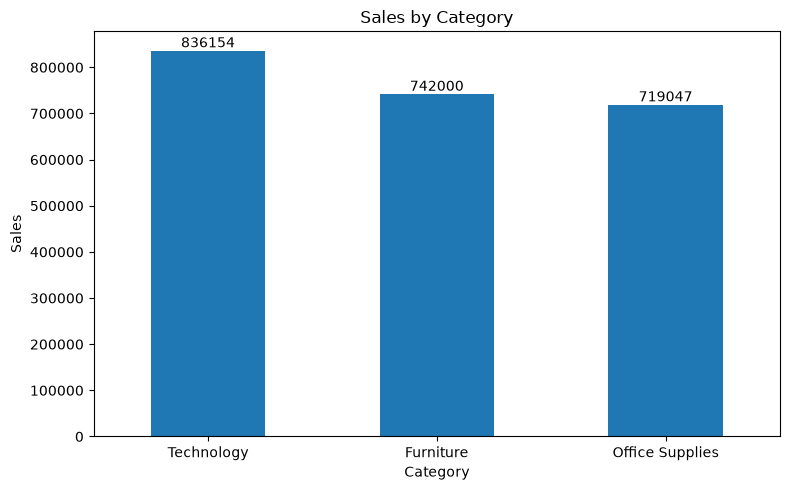

In [12]:
# Create bar chart
ax = category_sales.plot(kind="bar", figsize=(8,5))

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

# Customize chart
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

Technology generated the highest total sales, followed by Furniture and Office Supplies.

This indicates that Technology products are the primary contributors to the company's overall revenue.

### Business Insight

The Technology category represents the strongest revenue-generating segment and should remain a key focus for inventory planning, promotional campaigns, and product expansion.

Although Furniture and Office Supplies contribute substantial sales, further analysis is needed to evaluate whether these sales also translate into strong profitability.

## Business Question 4

### Which product categories generate the highest profit?

While sales indicate revenue generation, profit helps identify which product categories contribute the most to the company's earnings.

In [8]:
# Calculate total profit by category

category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

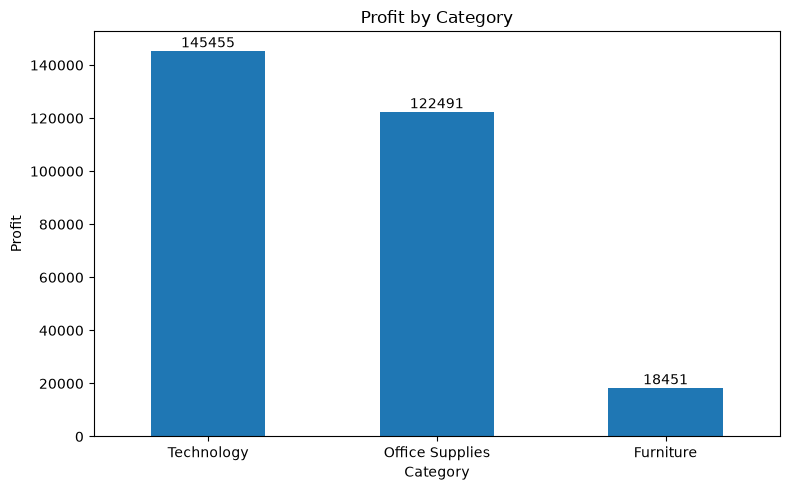

In [13]:
# Create bar chart
ax = category_profit.plot(kind="bar", figsize=(8,5))

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

# Customize chart
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

Technology generated the highest profit, followed by Office Supplies, while Furniture contributed the lowest profit among the three categories.

This suggests that high sales do not necessarily result in high profitability across all product categories.

### Business Insight

Technology is the most profitable category and should remain a strategic investment area.

Furniture requires further analysis to identify whether high discounts, shipping costs, or product mix are reducing profitability.

## Business Question 5

### Which sub-categories generate the highest sales?

Sub-category analysis provides a more detailed understanding of product performance within each category.

In [10]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

subcategory_sales

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

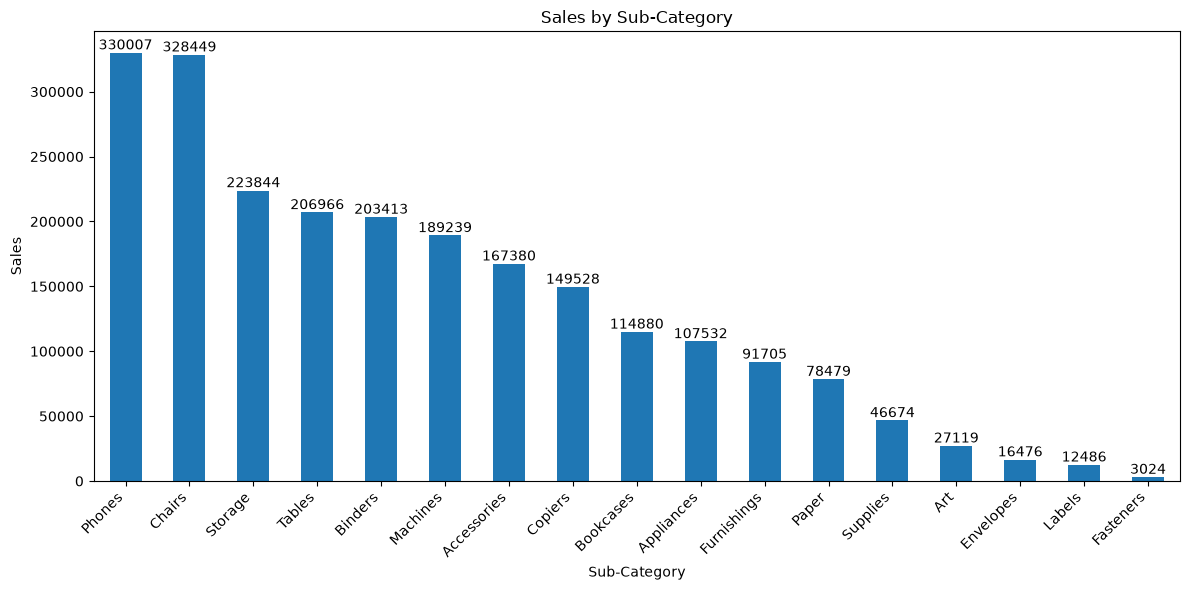

In [14]:
# Create bar chart
ax = subcategory_sales.plot(kind="bar", figsize=(12,6))

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

# Customize chart
plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observation

Phones generated the highest sales among all sub-categories, followed by Chairs, Storage, and Tables.

Fasteners, Labels, and Envelopes recorded the lowest sales, indicating relatively lower customer demand.

### Business Insight

High-performing sub-categories such as Phones and Chairs should be prioritized for inventory management and marketing campaigns to sustain revenue growth.

Low-performing sub-categories may require pricing reviews, targeted promotions, or evaluation of customer demand before increasing inventory investment.

## Business Question 6

### Which products generate the highest sales?

Identifying the top-selling products helps the business understand customer demand and prioritize inventory management and promotional strategies.

In [15]:
# Calculate total sales by product

top_products_sales = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products_sales

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [21]:
top_products_sales.index = [
    name[:25] + "..."
    if len(name) > 25 else name
    for name in top_products_sales.index
]

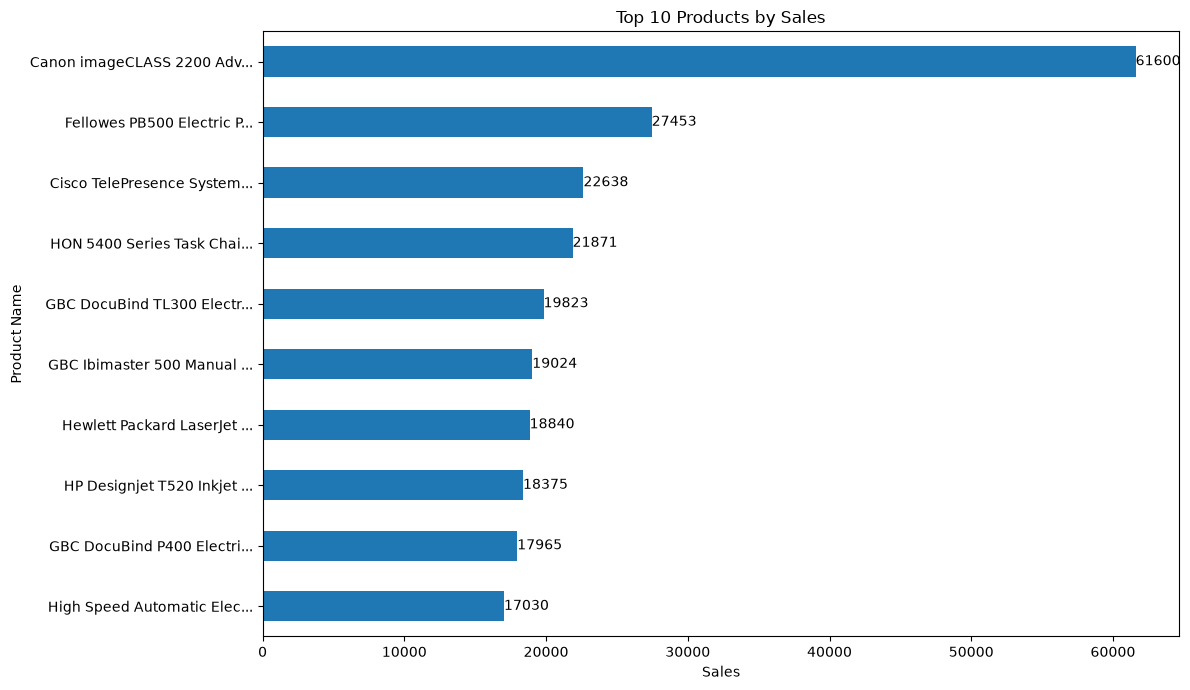

In [22]:
# Create horizontal bar chart

ax = top_products_sales.sort_values().plot(
    kind="barh",
    figsize=(12,7)
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

# Customize chart
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

### Observation

The chart identifies the top 10 products with the highest sales revenue.

These products contribute significantly to the company's total sales.

### Business Insight

The highest-selling products should be prioritized for inventory planning and marketing campaigns to maintain strong revenue performance.

Understanding customer demand for these products can also support forecasting and supply chain decisions.

## Business Question 7

### Which products generate the highest profit?

While high sales are important, the most profitable products contribute the greatest value to the business.

In [28]:
# Calculate total profit by product

top_products_profit = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products_profit

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

In [25]:
top_products_sales.index = [
    name[:25] + "..."
    if len(name) > 25 else name
    for name in top_products_sales.index
]

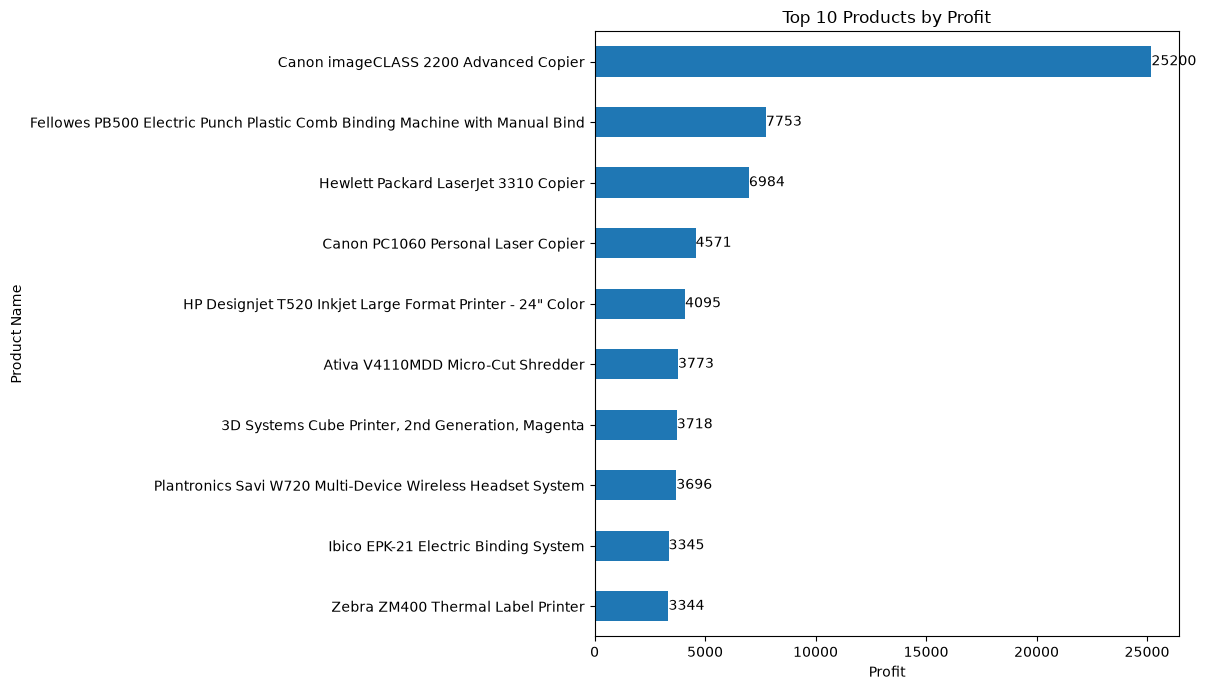

In [29]:
# Create horizontal bar chart

ax = top_products_profit.sort_values().plot(
    kind="barh",
    figsize=(12,7)
)

# Add value labels

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

# Customize chart

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.ylabel("Product Name")

plt.tight_layout()

plt.show()


### Observation

The **highest-profit product** is **<Product Name>**, followed by **<Product Name>** and **<Product Name>**.

The profit distribution indicates that a small number of products contribute significantly to the company's overall profitability.

### Business Insight

The highest-profit products should be prioritized through strategic inventory planning, premium positioning, and targeted marketing campaigns.

Products generating strong profits provide opportunities to maximize overall business performance and improve return on investment.

## Business Question 8

### How do monthly sales change over time?

Understanding monthly sales trends helps identify seasonality, growth patterns, and periods of high or low business activity.

This analysis supports forecasting and business planning.

In [30]:
# Convert Order Date to datetime

df["Order Date"] = pd.to_datetime(df["Order Date"])

In [34]:
# Create Month-Year column
df["Month-Year"] = df["Order Date"].dt.strftime("%b-%Y")

In [35]:
# Calculate monthly sales

monthly_sales = (
    df.groupby("Month-Year")["Sales"]
      .sum()
)

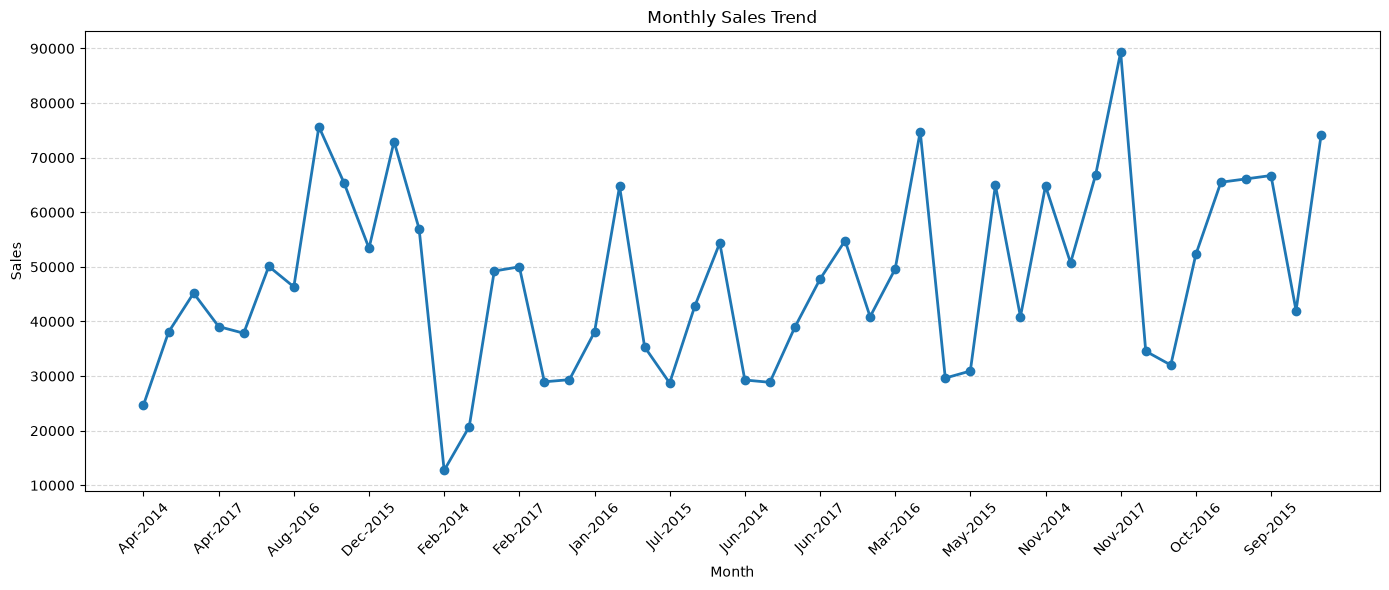

In [38]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

# Show every 3rd month on the x-axis
plt.xticks(
    ticks=range(0, len(monthly_sales), 3),
    labels=monthly_sales.index.astype(str)[::3],
    rotation=45
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

### Observation

Monthly sales fluctuated throughout the analysis period, showing several peaks and declines rather than a steady growth pattern.

Sales reached their highest level in **November 2017**, while **February 2014** recorded the lowest sales.

Overall, sales performance improved over time, with 2017 generating consistently higher monthly sales compared to earlier years.

### Business Insight

The strong increase in sales during late 2017 suggests higher customer demand, particularly in the final quarter of the year.

The business should ensure sufficient inventory, staffing, and marketing campaigns during peak sales months to maximize revenue.

Months with lower sales should be analyzed further to identify opportunities for promotional activities or operational improvements.

## Business Question 9

### Which regions generate the highest sales?

Analyzing sales by region helps identify high-performing markets and supports strategic decisions related to resource allocation, marketing, and regional expansion.

In [39]:
# Calculate total sales by region

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

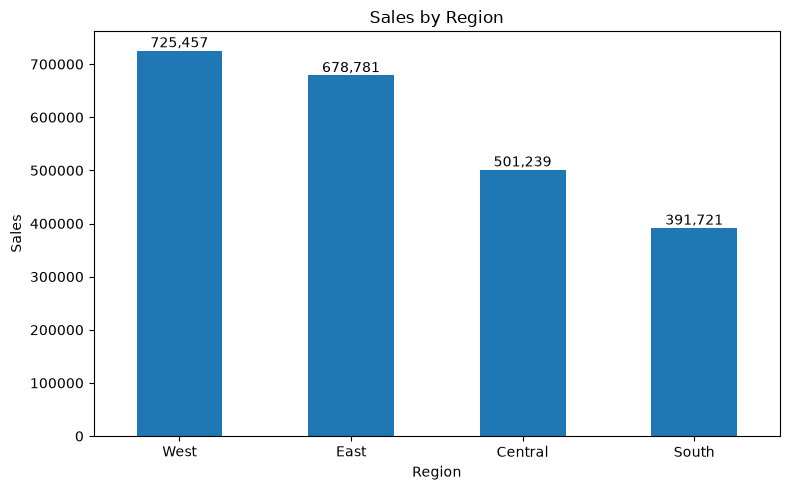

In [41]:
# Create bar chart

ax = region_sales.plot(
    kind="bar",
    figsize=(8,5)
)

# Add value labels

for container in ax.containers:
   labels = [f"{int(v):,}" for v in container.datavalues]
ax.bar_label(container, labels=labels)
# Customize chart

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Observation

The **West** region generated the highest total sales, recording **725,458**, followed closely by the **East** region with **678,781** in sales.

The **Central** region generated **501,240** in sales, while the **South** region recorded the lowest sales at **391,722**.

The results indicate that the West and East regions are the company's strongest revenue-generating markets.

### Business Insight

The West and East regions should remain priority markets for inventory allocation, customer retention, and marketing investments due to their strong sales performance.

The South region presents an opportunity for growth. Further analysis should be conducted to identify factors such as customer demand, product availability, pricing strategies, or regional competition that may be affecting sales performance.

## Business Question 10

### Which states generate the highest sales?

State-level analysis helps identify the strongest geographic markets and supports regional sales planning.

In [42]:
# Calculate top 10 states by sales

state_sales = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

state_sales

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

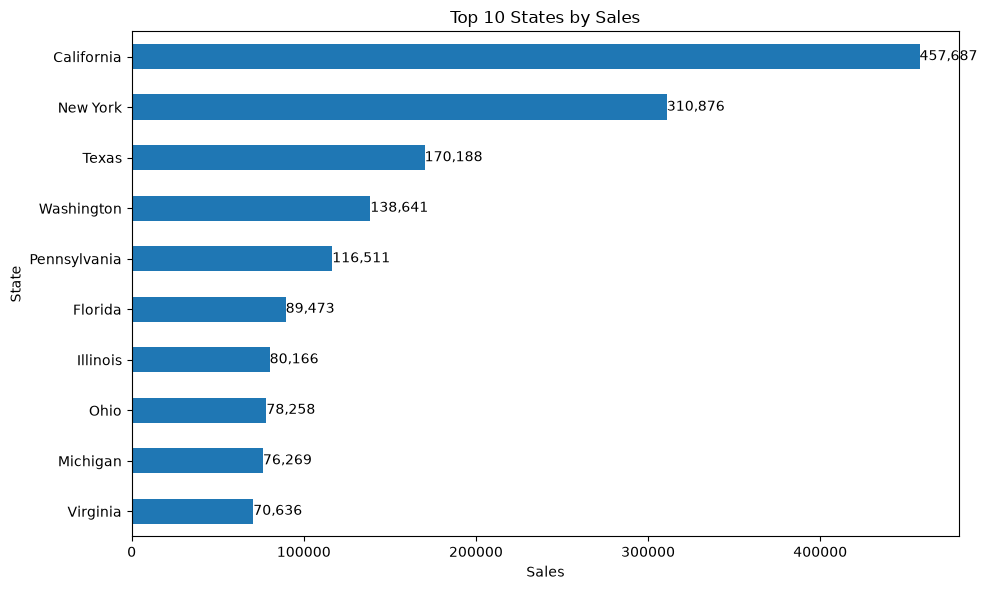

In [44]:
# Create horizontal bar chart

ax = state_sales.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

# Add value labels

for container in ax.containers:
    labels = [f"{int(v):,}" for v in container.datavalues]
ax.bar_label(container, labels=labels)

# Customize chart

plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")

plt.tight_layout()

plt.show()

### Observation

California generated the highest total sales, recording **457,688**, followed by **New York** with **310,876** in sales.

There is a significant gap between the top two states and the remaining states. **Texas** ranked third with **170,188** in sales, while **Virginia** recorded the lowest sales among the top 10 states at **70,637**.

The results indicate that California and New York are the company's strongest state-level markets.

### Business Insight

California and New York should remain strategic focus areas for marketing investments, inventory planning, and customer retention initiatives due to their substantial contribution to overall sales.

The company should also analyze the factors driving success in these states and apply similar strategies in lower-performing markets to improve sales performance.

### Recommendation

- Continue investing in high-performing markets such as California and New York.
- Evaluate successful sales strategies used in these states and replicate them in lower-performing regions.
- Conduct further analysis to identify factors limiting sales growth in other states.

## Business Question 11

### Which customer segments generate the highest sales?

Understanding sales by customer segment helps the business identify its most valuable customer groups and tailor marketing strategies accordingly.

In [45]:
# Calculate total sales by customer segment

segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

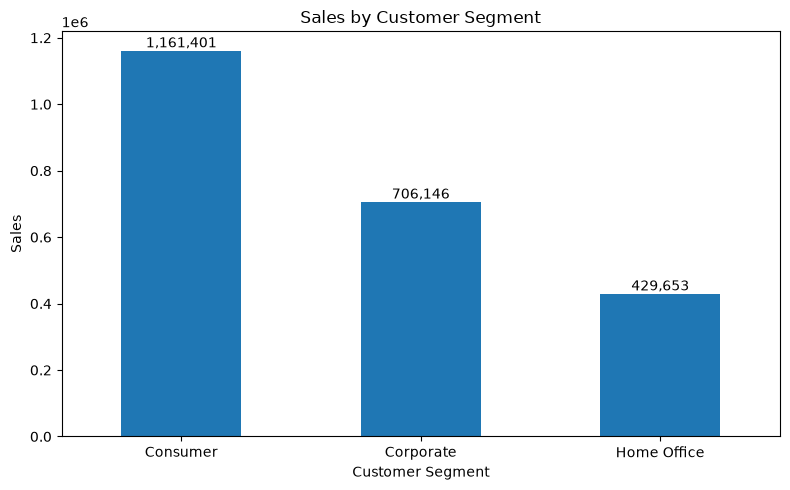

In [46]:
# Create bar chart

ax = segment_sales.plot(
    kind="bar",
    figsize=(8,5)
)

# Add value labels

for container in ax.containers:
   labels = [f"{int(v):,}" for v in container.datavalues]
ax.bar_label(container, labels=labels)

# Customize chart

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Observation

The **Consumer** segment generated the highest total sales, contributing **1,161,401** in revenue.

The **Corporate** segment ranked second with **706,146** in sales, while the **Home Office** segment generated the lowest sales at **429,653**.

The results indicate that individual consumers represent the company's largest customer segment and contribute the majority of overall sales.

### Business Insight

The Consumer segment should remain the primary focus for marketing campaigns, customer engagement, and loyalty programs due to its significant contribution to total sales.

The Corporate and Home Office segments present opportunities for growth through targeted promotions, customized product offerings, and strategic sales initiatives.

## Business Question 12

### How does discount affect profit?

Discounts are commonly used to increase sales, but excessive discounts can reduce profitability.

This analysis examines the relationship between discount and profit to determine whether higher discounts negatively impact business performance.

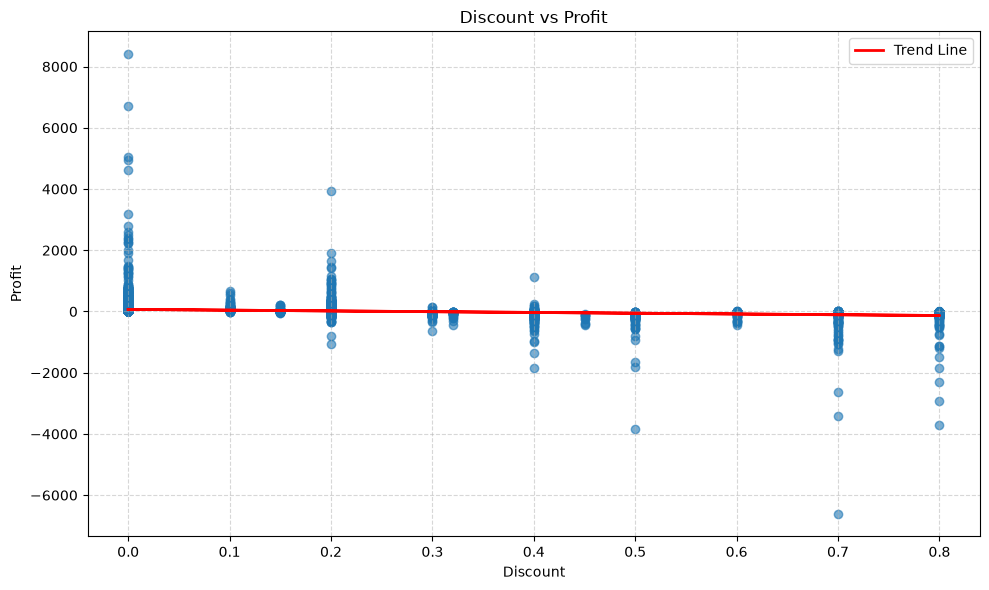

In [51]:
# Create scatter plot

plt.figure(figsize=(10,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.6
)

# Add trend line
z = np.polyfit(df["Discount"], df["Profit"], 1)
p = np.poly1d(z)

plt.plot(
    df["Discount"],
    p(df["Discount"]),
    color="red",
    linewidth=2,
    label="Trend Line"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

### Observation

The scatter plot reveals a negative relationship between discount and profit, as illustrated by the downward-sloping trend line.

Orders with low or no discounts generally generate higher profits, while orders with larger discounts are more likely to result in lower profits or financial losses.

The largest losses are observed at discount levels of **70%** and **80%**, indicating that excessive discounting has a significant impact on profitability.

### Business Insight

The analysis suggests that although discounts can encourage sales, offering excessive discounts substantially reduces profitability.

The company should review its pricing and promotional strategies, particularly for discounts of **70% and above**, to ensure they remain financially sustainable.

A product-level analysis could further identify which products or categories experience the greatest profit loss under high-discount scenarios.

# Executive Summary

After completing the exploratory data analysis, several important business insights were identified from the retail sales dataset.

The analysis examined sales performance, profitability, customer behavior, product performance, geographic trends, and the relationship between discounts and profit.

## Key Findings

### Sales Performance

- The company generated strong overall sales across all product categories.
- Technology was the highest-performing category in terms of both sales and profit.
- Phones and other technology-related products were among the top-selling products.

### Geographic Performance

- The West region generated the highest sales, followed by the East region.
- California was the highest-performing state, while New York ranked second.

### Customer Analysis

- The Consumer segment contributed the largest share of total sales.
- Corporate and Home Office segments showed opportunities for further growth.

### Sales Trend

- Monthly sales generally increased over time.
- Sales peaked during the final months of 2017, indicating possible seasonal demand.

### Profitability

- Higher discount levels were associated with lower profits.
- Orders with discounts of 70% and 80% frequently resulted in financial losses.

## Business Recommendations

Based on the analysis, the following recommendations are suggested:

1. Continue investing in high-performing Technology products to sustain revenue growth.

2. Prioritize inventory management for top-selling products to avoid stock shortages.

3. Expand successful marketing strategies from the West region and California into lower-performing markets.

4. Strengthen customer retention programs for the Consumer segment while developing targeted campaigns for Corporate and Home Office customers.

5. Review discount policies to ensure promotional offers remain profitable, particularly for discounts above 50%.

6. Use seasonal sales trends to improve demand forecasting, inventory planning, and promotional scheduling.

# Conclusion

The exploratory data analysis provided valuable insights into sales performance, profitability, customer behavior, and regional trends.

The findings from this notebook can support data-driven decision-making across sales, marketing, inventory management, and pricing strategy.

The cleaned and analyzed dataset is now ready for Feature Engineering and visualization in Power BI.